<a href="https://colab.research.google.com/github/ndvphuc07/HW1/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
#23.1
import folium
from folium.plugins import MarkerCluster
m = folium.Map(location=[10.76133948053686, 106.66849248249918], zoom_start=14)
hospital = folium.FeatureGroup(name="Bệnh viện")
mall = folium.FeatureGroup(name="Trung tâm thương mại")
gov = folium.FeatureGroup(name="Hành chính")
ktx = folium.FeatureGroup(name="Ký túc xá")
sta = folium.FeatureGroup(name="Sân vận động")
folium.Marker([10.761165567941314, 106.668333561651], popup="UEH cơ sở B", tooltip="Click vào", icon=folium.Icon(color='red')).add_to(m)
folium.Marker([10.760833552754185, 106.66320316660604], popup="Sân vận động Thống Nhất", tooltip="Click vào", icon=folium.Icon(color='blue')).add_to(sta)
folium.Marker([10.756912557740716, 106.66434127412947], popup="Bệnh viện Phạm Ngọc Thạch", tooltip="Click vào",icon=folium.Icon(color='green')).add_to(hospital)
folium.Marker([10.760380032415087, 106.67198261432202], popup="Ký túc xá Nguyễn Chí Thanh", tooltip="Click vào",icon=folium.Icon(color='orange')).add_to(ktx)
folium.Marker([10.770623565864277, 106.66991475715811], popup="Vạn Hạnh Mall", tooltip="Click vào",icon=folium.Icon(color='purple')).add_to(mall)
folium.Marker([10.767936185977195, 106.66658095456509], popup="UBND Phường Diên Hồng", tooltip="Click vào",icon=folium.Icon(color='black')).add_to(gov)
hospital.add_to(m)
mall.add_to(m)
gov.add_to(m)
ktx.add_to(m)
sta.add_to(m)
folium.LayerControl().add_to(m)
m

In [24]:
#23.2
import folium,time
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
geolocator = Nominatim(user_agent="geoapi", timeout=10)
center_location = geolocator.geocode("UEH University Ho Chi Minh City")
center = (center_location.latitude, center_location.longitude)
places = [
    "Landmark 81 Ho Chi Minh City",
    "Bitexco Financial Tower Ho Chi Minh City",
    "Tan Dinh Church Ho Chi Minh City",
    "Saigon Central Post Office Ho Chi Minh City",
    "Saigon Zoo and Botanical Gardens",
    "Saigon Centre Ho Chi Minh City",
    "Notre Dame Cathedral Ho Chi Minh City",
    "Nguyen Hue Walking Street Ho Chi Minh City",
    "Tan Dinh Market Ho Chi Minh City",
    "Bui Vien Walking Street Ho Chi Minh City"
]
m = folium.Map(location=center, zoom_start=13)
folium.Marker(center,popup="UEH cơ sở A",icon=folium.Icon(color="red")).add_to(m)
# xử lý từng địa điểm
for place in places:
    try:
        loc = geolocator.geocode(place)
        time.sleep(1)
        if loc:
            point = (loc.latitude, loc.longitude)
            dist = geodesic(center, point).km
            folium.Marker(point,popup=f"Cách UEH cơ sở A: {dist:.1f} km",tooltip=place,icon=folium.Icon(color="blue")).add_to(m)
            folium.PolyLine( [center, point], color="blue",weight=3).add_to(m)
    except Exception as e:
        print(f"Không thể tìm thấy hoặc xử lý địa điểm: {place}. Lỗi: {e}")
m

In [35]:
#23.3
import folium
import numpy as np
from folium.plugins import HeatMap
center = [10.761165567941314, 106.668333561651]
latitudes = np.random.normal(center[0], 0.02, 100)
longitudes = np.random.normal(center[1], 0.02, 100)
data_heatmap = list(zip(latitudes, longitudes))
m_heatmap = folium.Map(location=center, zoom_start=13)
HeatMap(data_heatmap, radius=15, blur=20, min_opacity=0.5).add_to(m_heatmap)
folium.Marker(center, popup="UEH cơ sở B", icon=folium.Icon(color='red', icon='info-sign')).add_to(m_heatmap)
display(m_heatmap)

In [28]:
import folium
import pandas as pd
center = [10.7769, 106.7009]
m = folium.Map(location=center, zoom_start=11)
districts = [
    {"name":"Quận 1", "location":[10.7756,106.7009], "orders":950},
    {"name":"Quận 3", "location":[10.7829,106.6874], "orders":870},
    {"name":"Quận 5", "location":[10.7540,106.6677], "orders":620},
    {"name":"Bình Thạnh", "location":[10.8106,106.7091], "orders":710},
    {"name":"Phú Nhuận", "location":[10.7991,106.6800], "orders":540}
]
for d in districts:
    if d["orders"] >= 900: color = "red"
    elif d["orders"] >= 700: color = "orange"
    else: color = "green"
    folium.Circle(location=d["location"],radius=d["orders"] * 3,color=color,fill=True,fill_opacity=0.45,popup=f'{d["name"]}<br>Orders: {d["orders"]}').add_to(m)
m

In [39]:
#23.5
import folium
center_point = [10.7758, 106.7009]
m_service = folium.Map(location=center_point, zoom_start=12)
folium.Circle(location=center_point, radius=10000, color='gray', fill=True, fill_opacity=0.1, popup='Vùng 10km').add_to(m_service)
folium.Circle(location=center_point, radius=5000, color='blue', fill=True, fill_opacity=0.2, popup='Vùng 5km').add_to(m_service)
folium.Circle(location=center_point, radius=3000, color='red', fill=True, fill_opacity=0.3, popup='Vùng 3km').add_to(m_service)
folium.Marker(location=center_point, popup='Kho hàng', icon=folium.Icon(color='black')).add_to(m_service)
display(m_service)
# Đánh giá: Vùng 3km có khả năng tiếp cận tốt nhất, vùng 5km có khả năng tiếp cận tiêu chuẩn, vùng 10km có khả năng tiếp cận kém. Vậy nên phạm vi hoạt động tối ưu là 5km


In [40]:
pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 8.1 MB/s eta 0:00:00


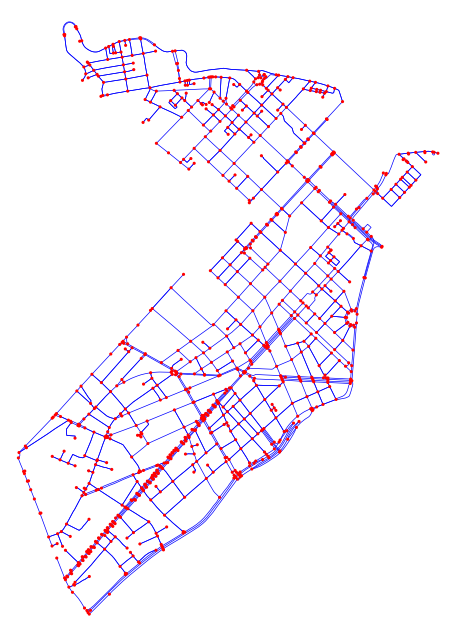

Khu vực: District 1, Ho Chi Minh City, Vietnam
Số lượng nút giao: 989
Số lượng đoạn đường: 2090
Chiều dài đường trung bình: 79.03 mét


In [44]:
#23.6
import osmnx as ox
import matplotlib.pyplot as plt
place_name = "District 1, Ho Chi Minh City, Vietnam"
graph = ox.graph_from_place(place_name, network_type='drive')
fig, ax = ox.plot_graph(graph, node_size=5, node_color='red', edge_color='blue', edge_linewidth=0.5, bgcolor='white')
stats = ox.basic_stats(graph)
print(f"Khu vực: {place_name}")
print(f"Số lượng nút giao: {stats['n']}")
print(f"Số lượng đoạn đường: {stats['m']}")
print(f"Chiều dài đường trung bình: {stats['edge_length_avg']:.2f} mét")
#Vai trò của dữ liệu mạng giao thông trong AI đô thị thông minh: Tối ưu hóa lộ trình, quản lý giao thông, quy hoạch hạ tầng, phát triển xe tự hành.

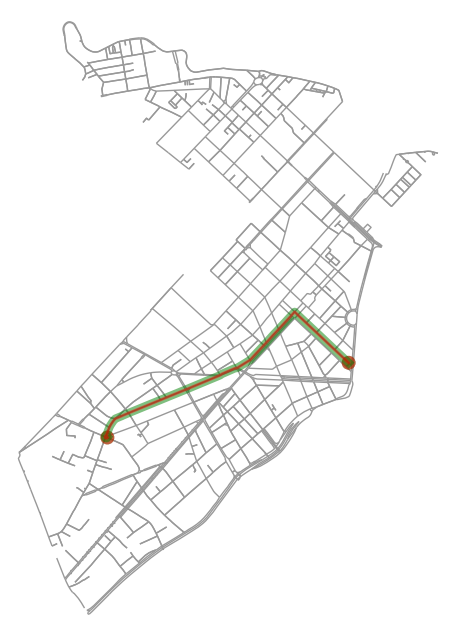

Điểm bắt đầu: 5247691973
Điểm kết thúc: 5464084931
Số lượng nút giao (Dijkstra): 28
Số lượng nút giao (A*): 28


In [62]:
#23.7
import networkx as nx
import osmnx as ox
import random
nodes_list = list(graph.nodes())
start_node = random.choice(nodes_list)
end_node = random.choice(nodes_list)
path_dijkstra = nx.shortest_path(graph, start_node, end_node, weight='length', method='dijkstra')
path_astar = nx.astar_path(graph, start_node, end_node, weight='length')
fig, ax = ox.plot_graph_routes(graph, [path_dijkstra, path_astar],
                                route_colors=['green', 'red'],
                                route_linewidths=[6, 2],
                                node_size=0, bgcolor='white')
print(f"Điểm bắt đầu: {start_node}")
print(f"Điểm kết thúc: {end_node}")
print(f"Số lượng nút giao (Dijkstra): {len(path_dijkstra)}")
print(f"Số lượng nút giao (A*): {len(path_astar)}")

In [64]:
#23.8
import folium
import numpy as np
from scipy.spatial import distance
center = [10.776, 106.700]
m_booking = folium.Map(location=center, zoom_start=14)
np.random.seed(42)
customers = np.random.normal(center, 0.01, (5, 2))
drivers = np.random.normal(center, 0.01, (5, 2))
dist_matrix = distance.cdist(customers, drivers)
assigned_drivers = []
available_drivers = list(range(5))
for i in range(5):
    dists = dist_matrix[i, available_drivers]
    closest_driver_idx = available_drivers[np.argmin(dists)]
    assigned_drivers.append(closest_driver_idx)
    available_drivers.remove(closest_driver_idx)
for i, (cust, drv_idx) in enumerate(zip(customers, assigned_drivers)):
    drv = drivers[drv_idx]
    folium.Marker(cust, popup=f'Khách hàng {i+1}', icon=folium.Icon(color='red', icon='user')).add_to(m_booking)
    folium.Marker(drv, popup=f'Tài xế được gán cho khách {i+1}', icon=folium.Icon(color='blue', icon='car')).add_to(m_booking)
    folium.PolyLine([cust, drv], color='black', weight=2, dash_array='5, 5').add_to(m_booking)
display(m_booking)
print("Hệ thống đã hoàn tất ghép cặp 5 khách hàng với 5 tài xế gần nhất.")

Hệ thống đã hoàn tất ghép cặp 5 khách hàng với 5 tài xế gần nhất.


In [73]:
#23.9
import folium
import numpy as np
from sklearn.cluster import KMeans
np.random.seed(10)
center_hcm = [10.776, 106.700]
locations = np.random.normal(center_hcm, 0.02, (20, 2))
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(locations)
centroids = kmeans.cluster_centers_
m_cluster = folium.Map(location=center_hcm, zoom_start=13)
colormap = ['red', 'blue', 'green']
for loc, cluster_id in zip(locations, clusters):
    folium.CircleMarker(
        location=loc,
        radius=6,
        color=colormap[cluster_id],
        fill=True,
        popup=f'Khách hàng cụm {cluster_id+1}'
    ).add_to(m_cluster)
for i, centroid in enumerate(centroids):
    folium.Marker(
        location=centroid,
        popup=f'Trạm trung chuyển tối ưu {i+1}',
        icon=folium.Icon(color='black', icon='star', prefix='fa')
    ).add_to(m_cluster)
display(m_cluster)
print("Giải thích quản trị:")
print("- Các khách hàng cùng màu thuộc cùng một nhóm logistics.")
print("- Các điểm ngôi sao đen là vị trí đặt kho/trạm giúp tối ưu hóa thời gian giao hàng và giảm chi phí vận chuyển.")

Giải thích quản trị:
- Các khách hàng cùng màu thuộc cùng một nhóm logistics.
- Các điểm ngôi sao đen là vị trí đặt kho/trạm giúp tối ưu hóa thời gian giao hàng và giảm chi phí vận chuyển.


In [79]:
#23.10
import folium
import numpy as np
center_hcm = [10.776, 106.700]
m_traffic = folium.Map(location=center_hcm, zoom_start=14)
segments = [
    {'path': [[10.771, 106.695], [10.776, 106.700]], 'score': 85},
    {'path': [[10.776, 106.700], [10.781, 106.705]], 'score': 92},
    {'path': [[10.771, 106.705], [10.776, 106.700]], 'score': 45},
    {'path': [[10.780, 106.690], [10.771, 106.695]], 'score': 20},
]
for seg in segments:
    if seg['score'] > 80: color = 'red'
    elif seg['score'] > 50: color = 'orange'
    else: color = 'green'
    folium.PolyLine(seg['path'], color=color, weight=8, opacity=0.8,
                    tooltip=f"Nguy cơ tắc nghẽn: {seg['score']}% HeadMap AI").add_to(m_traffic)
alt_route = [[10.780, 106.690], [10.785, 106.695], [10.785, 106.710]]
folium.PolyLine(alt_route, color='purple', weight=5, dash_array='10, 10',tooltip="Tuyến đường thay thế đề xuất (Tránh vùng đỏ)").add_to(m_traffic)
folium.Marker([10.785, 106.710], popup="Điểm đến an toàn", icon=folium.Icon(color='purple', icon='check')).add_to(m_traffic)
display(m_traffic)
print("Giải thích logic quản trị:")
print("- Hệ thống AI đánh giá dựa trên mật độ lưu lượng (Score).")
print("- Các đoạn màu đỏ cảnh báo khu vực có khả năng tê liệt giao thông.")
print("- Tuyến nét đứt màu tím là lộ trình thay thế tối ưu giúp phương tiện tránh các điểm nghẽn.")

Giải thích logic quản trị:
- Hệ thống AI đánh giá dựa trên mật độ lưu lượng (Score).
- Các đoạn màu đỏ cảnh báo khu vực có khả năng tê liệt giao thông.
- Tuyến nét đứt màu tím là lộ trình thay thế tối ưu giúp phương tiện tránh các điểm nghẽn.


In [83]:
#23.11
import folium
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
data = {
    'district': ['Quận 1', 'Quận 3', 'Quận 5', 'Quận 10', 'Quận Tân Bình', 'Quận 7'],
    'lat': [10.775, 10.783, 10.754, 10.771, 10.801, 10.732],
    'lon': [106.701, 106.687, 106.667, 106.665, 106.654, 106.721],
    'district_id': [[1], [2], [3], [4], [5], [6]],
    'past_demand': [120, 95, 60, 85, 110, 40]
}
df_demand = pd.DataFrame(data)
model = LinearRegression()
model.fit(df_demand['district_id'].tolist(), df_demand['past_demand'])
df_demand['predicted_demand'] = model.predict(df_demand['district_id'].tolist()) * 1.1
m_pred = folium.Map(location=[10.76, 106.68], zoom_start=12)
for _, row in df_demand.iterrows():
    val = row['predicted_demand']
    color = 'red' if val > 100 else 'orange' if val > 70 else 'green'
    folium.Circle(
        location=[row['lat'], row['lon']],
        radius=val * 10,
        color=color,
        fill=True,
        fill_opacity=0.6,
        popup=f"Dự báo nhu cầu {row['district']}: {int(val)} đơn/giờ"
    ).add_to(m_pred)
display(m_pred)
print("Thảo luận ý nghĩa điều phối:")
print(f"- Khu vực nhu cầu thấp nhất (Vùng Xanh): {df_demand.loc[df_demand['predicted_demand'].idxmin(), 'district']}")
print("- Quản trị viên nên điều phối bớt shipper từ Quận 7 sang các vùng đỏ để tối ưu công suất.")

Thảo luận ý nghĩa điều phối:
- Khu vực nhu cầu thấp nhất (Vùng Xanh): Quận 7
- Quản trị viên nên điều phối bớt shipper từ Quận 7 sang các vùng đỏ để tối ưu công suất.


In [87]:
#23.12
import folium
import random
from geopy.distance import geodesic
center_hcm = (10.776, 106.700)
hubs = {
    "Hub Đông": (10.795, 106.720),
    "Hub Tây": (10.760, 106.660),
    "Hub Nam": (10.730, 106.700)
}
random.seed(42)
customers = [(10.776 + random.uniform(-0.04, 0.04), 106.700 + random.uniform(-0.04, 0.04)) for _ in range(15)]
assignments = {name: [] for name in hubs}
for cust in customers:
    nearest_hub = min(hubs, key=lambda h: geodesic(cust, hubs[h]).km)
    assignments[nearest_hub].append(cust)
def optimize_route(start_node, points):
    if not points: return [], 0
    route = [start_node]
    current = start_node
    remaining = points[:]
    total_dist = 0
    while remaining:
        next_node = min(remaining, key=lambda p: geodesic(current, p).km)
        total_dist += geodesic(current, next_node).km
        route.append(next_node)
        current = next_node
        remaining.remove(next_node)
    total_dist += geodesic(current, start_node).km
    route.append(start_node)
    return route, total_dist
m_delivery = folium.Map(location=center_hcm, zoom_start=12)
colors = ["red", "blue", "green"]
total_km_optimized = 0
total_km_baseline = 0
for i, (hub_name, pts) in enumerate(assignments.items()):
    hub_loc = hubs[hub_name]
    total_km_baseline += sum(geodesic(hub_loc, p).km * 2 for p in pts)
    route_path, dist = optimize_route(hub_loc, pts)
    total_km_optimized += dist
    folium.Marker(hub_loc, popup=f"HUB: {hub_name}", icon=folium.Icon(color="black", icon="home")).add_to(m_delivery)
    for p in pts:
        folium.CircleMarker(location=p, radius=4, color=colors[i], fill=True).add_to(m_delivery)
    if len(route_path) > 1:
        folium.PolyLine(route_path, color=colors[i], weight=3, opacity=0.8, tooltip=f"Tuyến {hub_name}").add_to(m_delivery)
display(m_delivery)
print(f"Tổng quãng đường nếu giao lẻ từng đơn: {total_km_baseline:.2f} km")
print(f"Tổng quãng đường theo lộ trình tối ưu: {total_km_optimized:.2f} km")
print(f"Quãng đường tiết kiệm được: {total_km_baseline - total_km_optimized:.2f} km ({((total_km_baseline - total_km_optimized)/total_km_baseline)*100:.1f}%)")

--- KẾT QUẢ TỐI ƯU HÓA ---
Tổng quãng đường nếu giao lẻ từng đơn: 72.99 km
Tổng quãng đường theo lộ trình tối ưu: 39.24 km
Quãng đường tiết kiệm được: 33.75 km (46.2%)


In [90]:
#23.13
import folium
import random
center_point = [10.7760, 106.7000]
m_city = folium.Map(location=center_point, zoom_start=13)
service_points = folium.FeatureGroup(name="Điểm giao dịch")
coverage_zones = folium.FeatureGroup(name="Vùng kinh doanh")
network_links = folium.FeatureGroup(name="Tuyến đường")
for i in range(6):
    lat = center_point[0] + random.uniform(-0.02, 0.02)
    lon = center_point[1] + random.uniform(-0.02, 0.02)
    folium.Marker(
        location=[lat, lon],
        popup=f"Điểm số {i+1}",
        icon=folium.Icon(color='cadetblue', icon='info-sign')
    ).add_to(service_points)
folium.Circle(
    location=[10.7800, 106.7100], radius=1500,
    color="blue", fill=True, fill_opacity=0.2, popup="Vùng có nhu cầu lớn"
).add_to(coverage_zones)

folium.Circle(
    location=[10.7600, 106.6900], radius=1800,
    color="green", fill=True, fill_opacity=0.2, popup="Vùng tiềm năng"
).add_to(coverage_zones)
route_primary = [[10.755, 106.685], [10.776, 106.700], [10.795, 106.715]]
folium.PolyLine(route_primary, color="darkred", weight=6, opacity=0.8, tooltip="Tuyến chính").add_to(network_links)
route_secondary = [[10.770, 106.675], [10.785, 106.695], [10.790, 106.720]]
folium.PolyLine(route_secondary, color="darkblue", weight=4, dash_array='10, 10', tooltip="Tuyến dự phòng").add_to(network_links)
service_points.add_to(m_city)
coverage_zones.add_to(m_city)
network_links.add_to(m_city)
folium.LayerControl(collapsed=False).add_to(m_city)
display(m_city)

In [95]:
#23.14
import folium
import time
import numpy as np
base_station = [10.776, 106.700]
cars = [
    {"id": "Xe_A", "pos": [10.776, 106.700], "dest": [10.795, 106.715], "color": "red"},
    {"id": "Xe_B", "pos": [10.776, 106.700], "dest": [10.760, 106.680], "color": "blue"},
    {"id": "Xe_C", "pos": [10.776, 106.700], "dest": [10.785, 106.670], "color": "green"},
    {"id": "Xe_D", "pos": [10.776, 106.700], "dest": [10.755, 106.710], "color": "orange"}
]
for step in range(1,11):
    m_sim = folium.Map(location=base_station, zoom_start=14)
    folium.Marker(base_station, popup="Central Hub", icon=folium.Icon(color='black', icon='home')).add_to(m_sim)
    print(f"Thời điểm mô phỏng: T+{step}")
    for car in cars:
        curr_lat, curr_lon = car["pos"]
        dest_lat, dest_lon = car["dest"]
        new_lat = curr_lat + (dest_lat - curr_lat) * 0.25
        new_lon = curr_lon + (dest_lon - curr_lon) * 0.25
        car["pos"] = [new_lat, new_lon]
        dist_to_go = np.sqrt((dest_lat - new_lat)**2 + (dest_lon - new_lon)**2)
        status = "Hoàn thành" if dist_to_go < 0.002 else "Đang giao hàng"
        folium.Marker(
            location=car["pos"],
            popup=f"{car['id']}: {status}",
            icon=folium.Icon(color=car["color"], icon='car', prefix='fa')
        ).add_to(m_sim)

        folium.PolyLine([car["pos"], car["dest"]], color=car["color"], weight=2, dash_array='5, 5').add_to(m_sim)
    display(m_sim)
    time.sleep(0.5)

Thời điểm mô phỏng: T+1


Thời điểm mô phỏng: T+2


Thời điểm mô phỏng: T+3


Thời điểm mô phỏng: T+4


Thời điểm mô phỏng: T+5


Thời điểm mô phỏng: T+6


Thời điểm mô phỏng: T+7


Thời điểm mô phỏng: T+8


Thời điểm mô phỏng: T+9


Thời điểm mô phỏng: T+10


### 23.15: Ứng dụng AI Phân tích Vị trí Mở Cửa hàng (Smart Site Selection)
**Bài toán**: Xác định điểm kinh doanh tối ưu dựa trên dữ liệu giao thông và rủi ro vận hành.
**Dữ liệu**: Tọa độ, Lưu lượng xe (Volume), Tốc độ (Speed).
**Phương pháp**: Tính toán chỉ số Risk Score mô phỏng AI để phân loại địa điểm.

In [97]:
import folium
import pandas as pd
import numpy as np
np.random.seed(42)
data_sites = {
    'lat': np.random.uniform(10.74, 10.80, 35),
    'lon': np.random.uniform(106.66, 106.72, 35),
    'traffic_volume': np.random.randint(100, 500, 35),
    'avg_speed': np.random.randint(10, 60, 35)
}
df_sites = pd.DataFrame(data_sites)
def calculate_risk(row):
    score = (row['traffic_volume'] * 0.1) + (60 - row['avg_speed']) * 0.5
    return round(score, 1)
df_sites['risk_score'] = df_sites.apply(calculate_risk, axis=1)
m_site = folium.Map(location=[10.77, 106.69], zoom_start=13)
for _, row in df_sites.iterrows():
    if row['risk_score'] > 50:
        color, icon = 'red', 'exclamation-triangle'
        label = "Rủi ro cao (Tắc nghẽn)"
    elif row['risk_score'] > 30:
        color, icon = 'orange', 'info-circle'
        label = "Trung bình"
    else:
        color, icon = 'green', 'check-circle'
        label = "Tiềm năng lớn (Vùng Xanh)"
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Score: {row['risk_score']}<br>Traffic: {row['traffic_volume']}",
        tooltip=label,
        icon=folium.Icon(color=color, icon=icon, prefix='fa')
    ).add_to(m_site)
display(m_site)
print("Giá trị quản trị: Hệ thống giúp lọc bỏ 20% vị trí rủi ro cao và tập trung ngân sách vào các 'Vùng Xanh' có điểm rủi ro thấp.")

Giá trị quản trị: Hệ thống giúp lọc bỏ 20% vị trí rủi ro cao và tập trung ngân sách vào các 'Vùng Xanh' có điểm rủi ro thấp.
